### Ladda Pythonpaket

In [1]:
import numpy as np
import sympy as sp
from numpy import linalg as LA
import math as mt
#from matplotlib.image import imread
import matplotlib.pyplot as plt
from matplotlib import rcParams # for changing default values
import scipy.io as sio
import scipy.optimize
from scipy.optimize import minimize
from scipy.optimize import fsolve
from scipy.integrate import odeint
import os


## SymPy

Vad är SymPy? 

Enligt chat-GPT så är SymPy ett Python-bibliotek för symbolisk matematik. Med Sympy kan du utföra algebraiska beräkningar med symboliska variabler, differentiera och integrera uttryck, lösa ekvationer och utföra andra matematiska operationer med symboliska uttryck. Det är en kraftfull och flexibel verktygslåda för symbolisk matematik i Python och användbart för akademiska ändamål, forskning och ingenjörsarbete där exakt matematisk manipulation är nödvändig.

### Initiera SymPy variabler och utför enklare operationer

In [2]:
a, b, x =sp.symbols('a,b,x')
y1=a*x+b
y2=2*a*x+b
print(f'skillnaden mellan y2 och y1 är: {y2-y1}')


skillnaden mellan y2 och y1 är: a*x


### Expandera uttryck

In [3]:
y3=(2*a*x-b)**2
print(f'y3={y3}')
print(f'y3={sp.expand(y3)}')

y3=(2*a*x - b)**2
y3=4*a**2*x**2 - 4*a*b*x + b**2


### Övning:

Expandera $(x+a)^4$

### Förenkla uttryck

In [4]:
y4=(a*x-b)**2
print(f'y4-y3={y4-y3}')
print(f'y4-y3={sp.simplify(y4-y3)}')

y4-y3=(a*x - b)**2 - (2*a*x - b)**2
y4-y3=a*x*(-3*a*x + 2*b)


### Övning

Förenkla $(x+a)^4-(x-a)^4$

### Se ytterligare operationer på https://docs.sympy.org/latest/tutorials/intro-tutorial/simplification.html

### Sätt in numeriskt värde istället för SymPy variabel

In [5]:
print(f'y4= {y4.subs({a:3.,b:1.})}')

y4= 9.0*(x - 0.333333333333333)**2


### Lös linjär ekvation

$$
a \,x+b=0
$$

In [6]:
ekvation=a*x+b
print(ekvation)
sol=sp.solve(ekvation,x)
print(f'x = {sol}')

a*x + b
x = [-b/a]


### Lös system av linjära ekvationer

$$
\begin{split}
a \, x_1+2 \, a\, x_2+b=0 \\
x_1-2 \, x_2-b =0\\
\end{split}
$$

In [7]:
a, b, x1, x2 =sp.symbols('a, b, x1, x2')
ekvationer=[a*x1+2*a*x2+b,x1-2*x2-b]
sol=sp.solve(ekvationer,[x1,x2])
print(f'x1= {sol[x1]}')
print(f'x2= {sol[x2]}')

x1= (a*b - b)/(2*a)
x2= (-a*b - b)/(4*a)


### Övning

Bestäm $x_1$, $x_2$ och $x_3$ från:
$$
\begin{split}
-a \, x_1+2 \, a\, x_2-3 \, x_3+b=0 \\
x1-2\,x_2-b \, x_3=0\\
 a\,x_2+x_3=0
\end{split}
$$


### Definiera SymPy funktion och derivera

In [8]:
x=sp.symbols('x')
y=sp.Function('y')(x)
y=x**3
print(y)
print(sp.diff(y,x))
print(sp.diff(y,x,2))
print(sp.diff(y,x,3))


x**3
3*x**2
6*x
6


### Övning

Derivera 
$$
y(x)=\frac{2 \, x^2}{(x-1)^2 \, (1+x^2)}
$$
2 gånger.



### Bestäm primitiv funktion

In [9]:
primitiv_funktion=sp.integrate(y,x)
print(primitiv_funktion)

x**4/4


### Övning

Bestäm
$$
\int \frac{2 \, \sin(2 \ t)+3 \, \cos( t)}{\sin^2( t)} \, {\rm d}t
$$

### Integrera funktion

In [10]:

integral=sp.integrate(y,(x,3,10))
print(f'integral= {integral} eller numeriskt {float(integral)}')

integral= 9919/4 eller numeriskt 2479.75


### Övning

Bestäm 
$$
\bar{y}=\frac{ \int_0^1 \int_0^\pi r^2 \, \sin(\theta) \,{\rm d}r \, {\rm d} \theta }
{ \int_0^1 \int_0^\pi r \,{\rm d}r \, {\rm d} \theta }
$$

### Definiera vektorer

In [11]:
x1, x2 =sp.symbols('x1, x2')
xvektor=sp.Matrix([x1,x2])
print(xvektor)
b1, b2 =sp.symbols('b1, b2')
bvektor=sp.Matrix([b1,b2])



Matrix([[x1], [x2]])


Alternativt (vilket är användbart då vektorn består av många komponenter)

In [14]:
 u_syms = sp.symbols('u1:7') # u1 ... u6
 uvektor = sp.Matrix(u_syms)
 print(uvektor)


Matrix([[u1], [u2], [u3], [u4], [u5], [u6]])


### Skalärprodukt mellan vektorer

In [15]:
print(xvektor.dot(bvektor))


b1*x1 + b2*x2


### Kryssprodukt mellan vektorer

In [17]:
c1, c2, c3 =sp.symbols('c1, c2, c3')
cvektor=sp.Matrix([c1, c2, c3])
d1, d2, d3 =sp.symbols('d1, d2, d3')
dvektor=sp.Matrix([d1, d2, d3])
print(cvektor.cross(dvektor))

Matrix([[c2*d3 - c3*d2], [-c1*d3 + c3*d1], [c1*d2 - c2*d1]])


### Övning

Bestäm skalär- och kryssprodukt mellan $\boldsymbol{a}=[\alpha, \, 1, (1-\alpha)]^T$ och $\boldsymbol{b}=[2\, \alpha, \, (2-\alpha), \alpha]^T$

### Definiera matris

In [25]:
K11, K12, K21, K22=sp.symbols('K11, K12, K21, K22')
Kmatris2x2=sp.Matrix([[K11,K12],[K21,K22]])
print(Kmatris2x2)

Matrix([[K11, K12], [K21, K22]])


Alternativt (smidigare för större matriser)


In [22]:
K_syms = sp.symbols('K1:7_1:7')   # K11 ... K66
Kmatris = sp.Matrix(6, 6, K_syms)
print(Kmatris)
#eller
Kmatris = sp.Matrix(6, 6, lambda i, j: sp.symbols(f'K{i+1}{j+1}'))
print(Kmatris)

Matrix([[K1_1, K1_2, K1_3, K1_4, K1_5, K1_6], [K2_1, K2_2, K2_3, K2_4, K2_5, K2_6], [K3_1, K3_2, K3_3, K3_4, K3_5, K3_6], [K4_1, K4_2, K4_3, K4_4, K4_5, K4_6], [K5_1, K5_2, K5_3, K5_4, K5_5, K5_6], [K6_1, K6_2, K6_3, K6_4, K6_5, K6_6]])
Matrix([[K11, K12, K13, K14, K15, K16], [K21, K22, K23, K24, K25, K26], [K31, K32, K33, K34, K35, K36], [K41, K42, K43, K44, K45, K46], [K51, K52, K53, K54, K55, K56], [K61, K62, K63, K64, K65, K66]])


### Initiera SymPy matris med bara nollor

In [23]:
Kmatris2=sp.zeros(2,2)
print(Kmatris2)

Matrix([[0, 0], [0, 0]])


### Multiplicera matris med vektor

In [28]:
print(Kmatris2x2*xvektor)
#eller
print(Kmatris2x2 @ xvektor)

Matrix([[K11*x1 + K12*x2], [K21*x1 + K22*x2]])
Matrix([[K11*x1 + K12*x2], [K21*x1 + K22*x2]])


### Invertera matris

In [29]:
print(Kmatris2x2.inv())

Matrix([[K22/(K11*K22 - K12*K21), -K12/(K11*K22 - K12*K21)], [-K21/(K11*K22 - K12*K21), K11/(K11*K22 - K12*K21)]])


### Lös ekvationssytem

In [30]:
sol=sp.solve(Kmatris2x2*xvektor-bvektor,xvektor)
print(sol)
print(f'x1= {sol[x1]}')
print(f'x2= {sol[x2]}')

{x1: (-K12*b2 + K22*b1)/(K11*K22 - K12*K21), x2: (K11*b2 - K21*b1)/(K11*K22 - K12*K21)}
x1= (-K12*b2 + K22*b1)/(K11*K22 - K12*K21)
x2= (K11*b2 - K21*b1)/(K11*K22 - K12*K21)


### Kontrollera lösning 

In [32]:
sp.simplify( Kmatris2x2*xvektor.subs(sol) )

Matrix([
[b1],
[b2]])

### Bestäm egenvärden


In [33]:
print(Kmatris2x2.eigenvals())

{K11/2 + K22/2 - sqrt(K11**2 - 2*K11*K22 + 4*K12*K21 + K22**2)/2: 1, K11/2 + K22/2 + sqrt(K11**2 - 2*K11*K22 + 4*K12*K21 + K22**2)/2: 1}


### Lösning av differentialekvation
 $$
u''(x)+x=0 \quad \text{för} \; 0 \leq x \leq L
 $$
med randvillkor
$$
u(0)=2, \quad u'(L)=1
$$

In [34]:
x=sp.symbols('x')
u=sp.Function('u')(x)

diffekv=sp.diff(u,x,2)+x
sol=sp.dsolve(diffekv)
print(f'lösning u(x) ={sol.rhs} (dvs två integrationskonstanter)')

lösning u(x) =C1 + C2*x - x**3/6 (dvs två integrationskonstanter)


### Integrationskonstanter bestäms med hjälp av randvillkor

In [36]:
usol=sol.rhs
usol_prim=sp.diff(usol,x)
L,C1, C2=sp.symbols('L,C1, C2')
integrations_konstanter=sp.solve([usol.subs(x,0)-2,usol_prim.subs(x,L)-1],[C1,C2])
print(f'C1= {integrations_konstanter[C1]}')
print(f'C2= {integrations_konstanter[C2]}')

C1= 2
C2= L**2/2 + 1


### Insättning i $u(x)$

In [37]:
usol_=usol.subs(integrations_konstanter)
print(usol_)

-x**3/6 + x*(L**2/2 + 1) + 2


### Skapa funktion baserat på lösning, alt 1

In [38]:

def u_sol_fkn1(x,L):
    return -x**3/6 + x*(L**2/2 + 1) + 2


### Skapa funktion baserat på lösning, alt 2

In [39]:
u_sol_fkn2 = sp.lambdify((x,L),usol_,'numpy')

### Plotta resultat

För att plotta numeriska värden så används NumPy (se nedan för introduktion till NumPy)

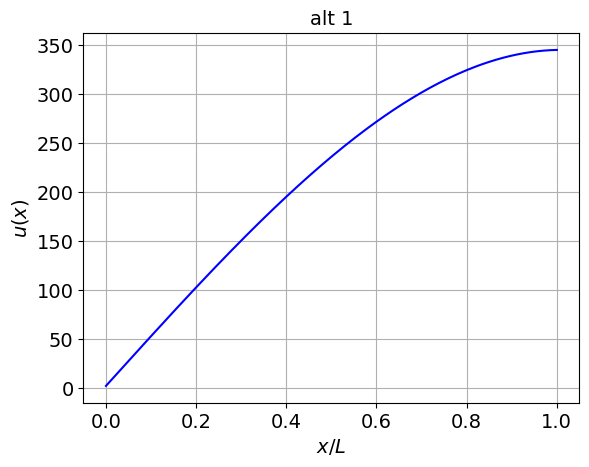

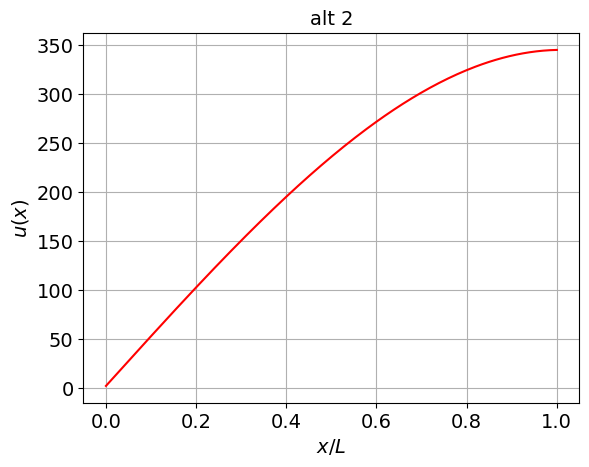

In [40]:

xi=np.linspace(0, 1., 200)
L=10. #sätt L=10 (exmpelvis)
x=xi*L

#plottning alt 1
plt.plot(xi,u_sol_fkn1(x,L),'b-')
plt.xlabel(r'$x/L$',fontsize='14')
plt.ylabel(r'$u(x)$',fontsize='14')
plt.title(r'alt 1',fontsize='14')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.show()

#plottning alt 2
plt.plot(xi,u_sol_fkn2(x,L),'r-')
plt.xlabel(r'$x/L$',fontsize='14')
plt.ylabel(r'$u(x)$',fontsize='14')
plt.title(r'alt 2',fontsize='14')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.show()

### Övning

Bestäm $w(x)$ från:
$$
\frac{{\rm d}^4 w}{{\rm d} x^4}-\frac{q_0 \, x}{EI}=0 \quad \text{för} \;0 \leq x \leq L
$$
med randvillkoren
$$
w(0)=w'(0)=w(L)=w'(L)=0 
$$

### Ingår ej i kursen: Heaviside funktion, Dirac-delta funktion

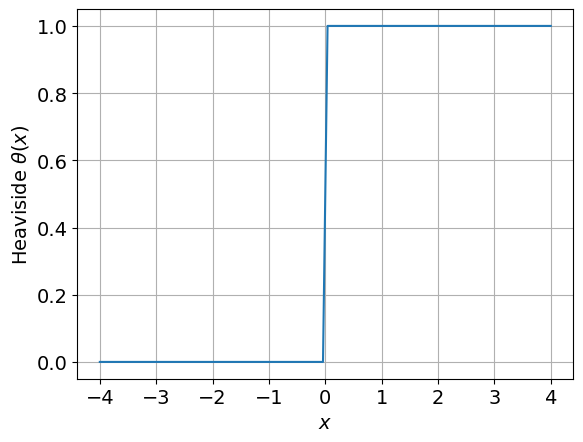

In [41]:
x=sp.symbols('x')
#skapa NumPy Heaviside
np_Heaviside=sp.lambdify((x),sp.Heaviside(x),'numpy')
#plotta Heaviside
xnp=np.linspace(-4,4,100)
plt.plot(xnp,np_Heaviside(xnp))
plt.xlabel(r'$x$',fontsize='14')
plt.ylabel(r'Heaviside $\theta(x)$',fontsize='14')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.show()

In [42]:
#Derivatan av Heavisde är Dirac delta funktionen
print(sp.diff(sp.Heaviside(x),x))

#Dvs om man integrerar fås Heavisde tillbaka
print(sp.integrate(sp.DiracDelta(x),x))

DiracDelta(x)
Heaviside(x)


### Ingår ej i kursen: Lös differentialekvation som innehåller Diracdeltafunktionen

$$
w''(x)-\delta(x-0.5)=0 \quad \text{för} \; 0 \leq x \leq 1
$$
med randvillkor $w(0)=0$, $w'(1)=1$.

w(x)=C1*x + C2 + (x - 0.5)*Heaviside(x - 0.5)
C1=0, C2=0
w=(x - 0.5)*Heaviside(x - 0.5)


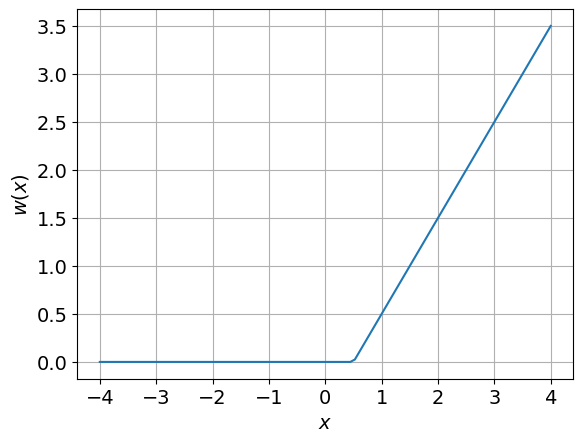

In [43]:
w = sp. Function ('w')(x)
diff_eq = sp. diff (w, x, x) - sp.DiracDelta(x-0.5)
C1,C2 =sp.symbols('C1 C2')
wprim=sp.integrate(sp.DiracDelta(x-0.5),x)+C1
w_=sp.integrate(wprim,x,meijerg=False)+C2   #OBS viktigt med meijerg=False
print(f'w(x)={w_}')
ekvationer=[w_.subs(x,0),wprim.subs(x,1)-1]
sol=sp.solve(ekvationer,[C1,C2])
print(f'C1={sol[C1]}, C2={sol[C2]}')
print(f'w={w_.subs(sol)}')
#skapa NumPyfunktion av lösningen
w_np=sp.lambdify((x),w_.subs(sol),'numpy')
#plotta lösning
xnp=np.linspace(-4,4,100)
plt.plot(xnp,w_np(xnp))
plt.xlabel(r'$x$',fontsize='14')
plt.ylabel(r'$w(x)$',fontsize='14')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.show()

### Ingår ej i kursen, balkexempel

In [45]:
x, EI, q0, L=sp.symbols('x, EI, q0, L',positive=True) #lägg till information om att variabler är >=0
w=sp.Function('w')(x)

diffekv=sp.diff(w,x,4)-sp.DiracDelta(x-L/2)/(EI*L)

C1,C2,C3,C4=sp.symbols('C1,C2,C3,C4')

wtriss=sp.integrate(sp.DiracDelta(x-L/2)/(EI*L),x)+C1
wbiss=sp.integrate(wtriss,x,meijerg=False)+C2   #OBS viktigt med meijerg=False
wprim=sp.integrate(wbiss,x,meijerg=False)+C3   
w_=sp.integrate(wprim,x,meijerg=False)+C4   
print(f'Lösning med okända integrationskonstanter: {w_}')
ekvationer=[w_.subs(x,0),w_.subs(x,L),wbiss.subs(x,0),wbiss.subs(x,L)]
integrations_konstanter=sp.solve(ekvationer,[C1,C2,C3,C4])
wsol_=w_.subs(integrations_konstanter)
print(f'Lösning w(x)={wsol_}')

Lösning med okända integrationskonstanter: C1*x**3/6 + C2*x**2/2 + C3*x + C4 + (-L**3/48 + L**2*x/8 - L*x**2/4 + x**3/6)*Heaviside(-L/2 + x)/(EI*L)
Lösning w(x)=L*x/(16*EI) - x**3/(12*EI*L) + (-L**3/48 + L**2*x/8 - L*x**2/4 + x**3/6)*Heaviside(-L/2 + x)/(EI*L)


## NumPy


Vad är NumPy? 

Enligt chat-GPT så är NumPy ett populärt Python-bibliotek som används för numerisk beräkning och datavetenskapliga tillämpningar. Biblioteket erbjuder stöd för effektiv hantering av arrayer och matriser samt inbyggda funktioner för att utföra olika matematiska operationer på dessa strukturer. NumPy utgör grundstenen för många andra Python-bibliotek inom vetenskapliga beräkningar och maskininlärning, och det möjliggör snabb och effektiv numerisk databehandling. Med NumPy kan användare utföra avancerade matematiska operationer, skapa och manipulera stora datamängder och arbeta med flerdimensionella arrayer på ett enkelt och effektivt sätt.

If you are used to Matlab then see: https://numpy.org/doc/stable/user/numpy-for-matlab-users.html

### Definiera NumPy vektor och matris 

In [46]:
x = np.array([1., 2., 3.])
A = np.array([[1., 2., 3.], [2., 4., 5.], [3., 5., 6.]])
print('x=',x)
print('A=',A)

x= [1. 2. 3.]
A= [[1. 2. 3.]
 [2. 4. 5.]
 [3. 5. 6.]]


### Multiplicera dessa

In [47]:
b=A@x
print('b=',b)

b= [14. 25. 31.]


### Skalärprodukt mellan två vektorer

In [48]:
v1 = np.array([1., 2., 3.])
v2 = np.array([4., 5., 6.])
#alternativ 1
v3=v1@v2
print(f'v3={v3}')
#alternativ 2, långsamt
v3=0.
for i in range(len(v1)):
    v3+=v1[i]*v2[i]
print(f'v3={v3}')

v3=32.0
v3=32.0


### Kryssprodukt mellan två vektorer

In [49]:
v3=np.cross(v1,v2)
print('v3=',v3)

v3= [-3.  6. -3.]


### Multiplikation mellan matriser

In [50]:
A = np.array([[1., 2.], [2., 4.], [3., 5.]])
B = np.array([[1., 2., 3.], [2., 4., 5.]])
C=A@B
print('C=',C)

C= [[ 5. 10. 13.]
 [10. 20. 26.]
 [13. 26. 34.]]


### Elementvis multiplikation av matriser (OBS ej matrismultiplikation)

In [51]:
A = np.array([[1., 2.], [2., 4.]])
B = np.array([[5., 6.], [7., 8.]])
print(A*B)

[[ 5. 12.]
 [14. 32.]]


### Invers av matris

In [52]:
A = np.array([[1., 2., 3.], [2., 4., 5.], [3., 5., 6.]])
Ainv=np.linalg.inv(A)
print('Invers av A=',Ainv)

Invers av A= [[ 1. -3.  2.]
 [-3.  3. -1.]
 [ 2. -1.  0.]]


### Lös ekvationssystem $$A \, x=b$$

In [53]:
A = np.array([[1., 2., 3.], [2., 4., 5.], [3., 5., 6.]])
b=np.array([6,7,8])
#alternativ 1, långsammare
x=np.linalg.inv(A)@b
print('alt 1 x=',x)
#alternativ 2, snabbare
x=np.linalg.solve(A,b)
print('alt 2 x=',x)


alt 1 x= [ 1. -5.  5.]
alt 2 x= [ 1. -5.  5.]


### Egenvärden och egenvektorer

In [54]:
A = np.array([[1., 2.], [2., 3.]])
la, vektorer=np.linalg.eig(A)
print(f'egenvärden: {la}')
print(f'egenvektorer: {vektorer}')


egenvärden: [-0.23606798  4.23606798]
egenvektorer: [[-0.85065081 -0.52573111]
 [ 0.52573111 -0.85065081]]


### Definition av speciella matriser

In [55]:
print(f'enhetsmatris: {np.eye(3)}')
print(f'nollmatris: {np.zeros((3,3))}')


enhetsmatris: [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
nollmatris: [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


### Elementvis summation

In [56]:
#summera elementvus
A = np.array([1., 2., 3.])
print(np.sum(A))

A = np.array([[1., 2.], [3., 7.]])
print(np.sum(A))


#summa av diagonalvärden
A = np.array([[1., 2.], [3., 7.]])
print(np.trace(A))

#diagonalvärden
print(np.diag(A))


6.0
13.0
8.0
[1. 7.]


### Plottning

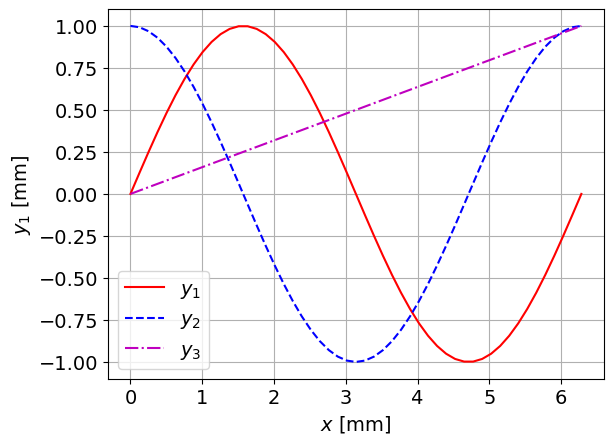

In [57]:
#skapa grid längs x-axeln
x = np.linspace(0, 2*np.pi, 51) #mm  
L=1. #mm
#Tre olika kurvor
y1 = np.sin(x/L)
y2 = np.cos(x/L)
y3= x/(2.*np.pi)
plt.plot(x,y1,'r-')
plt.plot(x,y2,'b--')
plt.plot(x,y3,'m-.')

plt.xlabel(r'$x$ [mm]',fontsize='14')
plt.ylabel(r'$y_1$ [mm]',fontsize='14')
plt.legend(['$y_1$','$y_2$','$y_3$'],fontsize='14')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()

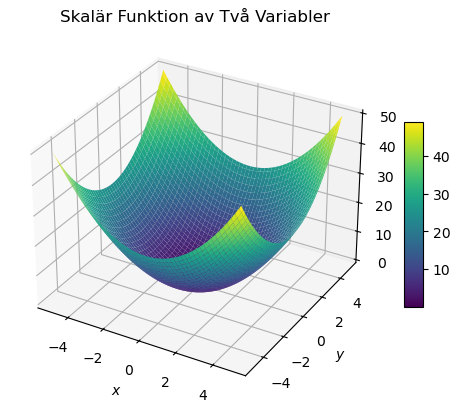

In [58]:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Definiera den skalära funktionen av två variabler
def f(x, y):
    return x**2 + y**2

# Generera x- och y-värden
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

# Skapa ett meshgrid från x och y
X, Y = np.meshgrid(x, y)

# Beräkna funktionsvärden för varje par (x, y)
Z = f(X, Y)

# Skapa en 3D-plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotta ytan
surface = ax.plot_surface(X, Y, Z, cmap='viridis')

# Lägg till en färgskala
fig.colorbar(surface, ax=ax, shrink=0.5, aspect=10)

# Ange axel-etiketter
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

# Ange titeln
ax.set_title('Skalär Funktion av Två Variabler')

# Visa plotten
plt.show()





### Övning

Plotta $w_1(x)$ och $w_2(x)$ då
$$
w_1(x)=-\frac{L^2 \, q_0 \, x^2}{(60\,EI)} + \frac{L \, q_0 \, x^3}{40 \, EI} - \frac{q_0 \, x^5}{120 \,EI \, L}
$$
$$
w_2(x)=-\frac{7\,L^3\,q_0\,x}{360\,EI} + \frac{L\,q_0\,x^3}{36\,EI} - \frac{q_0\,x^5}{120\,EI\,L}
$$
för $EI=200\cdot 10^6$ N mm$^$2, $q_0=1$ N/mm, $L=1000$ mm.

### Numerisk lösning av Ordinära DifferentialEkvationer (ODE)

$$
\dot{u}=k \,u+1/m \,\sin(2 \, t) \quad \text{för} \; 0 \leq t\leq \pi
$$
med initialvillkor $u(0)=1$ och $m=2$ samt $k=3$.

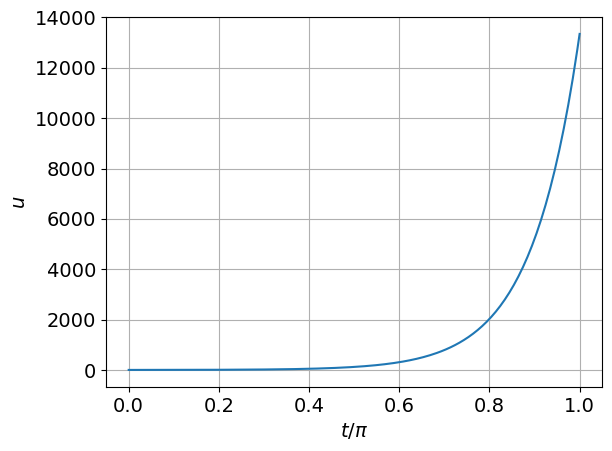

In [59]:
m=2
k=3.
#tidsintervall (med 200 tidssteg)
tspan=np. linspace (0, np.pi, 200)

#initialvillkor
u0=1.

#differentialekvationsfunktion
def my_ode(u,t,m,k):
    return k*u+1/m*np.sin(2.*t)

#Lös ode
usol = odeint ( my_ode , u0 , tspan , args =(m,k))

# Plotta resultaten
plt.plot(tspan/np.pi,usol)
plt.xlabel(r'$t/\pi$',fontsize='14')
plt.ylabel(r'$u$',fontsize='14')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.show()



### Numerisk lösning av sytem av Ordinära DifferentialEkvationer (ODE)

$$
\begin{split}
\dot{u}_1=-k/m \, u_2+F_0/m \,\,t/t_1 \\
\dot{u}_2=u_1\\
\end{split}
$$
för $0 \leq t\leq 6$ med initialvillkoren $u_1(0)=u_2(0)=0$, Antag $m=1$, $k=10$, $F_0=10$, $t_1=1$.

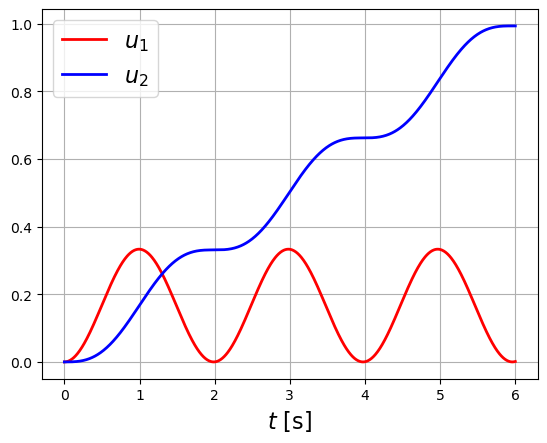

In [60]:
# Indata
m = 1; k = 10; F0 = 10; t1 = 6

# Tidshistoria
tspan = np.linspace(0, t1, 1000)

# Initialvillkor
ubar0 = np.array([0, 0])

# Differentialekvation
def odefcn1a(ubar, t, m, k, F0, t1):
    dubardt = np.zeros(2)
    dubardt[0] = -k / m * ubar[1] + F0/m * t / t1
    dubardt[1] = ubar[0]
    return dubardt

# Lös differentialekvationen
ubar = odeint(odefcn1a, ubar0, tspan, args=(m, k, F0, t1))

# Plotta resultaten
plt.plot(tspan, ubar[:, 0], 'r-', label=r'$u_1$', linewidth=2)
plt.plot(tspan, ubar[:, 1], 'b', label=r'$u_2$', linewidth=2)
plt.xlabel('$t$ [s]', fontsize=16)
plt.legend(fontsize=16)
plt.grid(True)
plt.show()

### Övning
Plotta $u_1(t)$ och $u_2(t)$ då 
$$
\begin{split}
\dot{u}_1=-c / m \, u_1-k/m \, u_2+F_0/m \,\,t/t_1 \\
\dot{u}_2=u_1\\
\end{split}
$$
för $0 \leq t\leq 6$ med initialvillkoren $u_1(0)=u_2(0)=0$, Antag $m=1$, $c=1$, $k=10$, $F_0=10$, $t_1=1$.

### Ingår ej i kursen: Lösning av icke-linjära ekvationer

In [61]:
# Definiera det icke-linjära ekvationssystemet
def ekvationer(vars):
    x = vars
    ekv =  np.sin(x/L) - x/(2.*np.pi)
    return ekv

# Initial gissning
initial_gissning = 3.

# Lös ekvationssystemet
lösning = fsolve(ekvationer, initial_gissning)

# Visa lösningen
print("Lösning av ekvationssystemet:", lösning)


Lösning av ekvationssystemet: [2.69779962]


In [62]:
# Definiera det icke-linjära ekvationssystemet
def ekvationer(vars):
    x, y, z = vars
    ekv1 = x**2 + y - 4
    ekv2 = x + y + z**2 - 9
    ekv3 = z - 2*x*y
    return [ekv1, ekv2, ekv3]

# Initial gissning
initial_gissning = [1, 2, 3]

# Lös ekvationssystemet
lösning = fsolve(ekvationer, initial_gissning)

# Visa lösningen
print("Lösning av ekvationssystemet:", lösning)


Lösning av ekvationssystemet: [1.81634434 0.70089324 2.54612694]


### Ingår ej i kursen: Optimering utan bivillkor

In [63]:
def rosenbrock(x):
    a = 1
    b = 10
    return (a - x[0]) ** 2 + b * (x[1] - x[0] ** 2) ** 2
x0 = np.array([1.3, 0.7])
res = minimize(rosenbrock, x0, method='nelder-mead',
               options={'xatol': 1e-8, 'disp': True})
print('Result with Nelder-Mead:',res.x)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 74
         Function evaluations: 144
Result with Nelder-Mead: [1. 1.]


### Ingår ej i kursen: Optimering med bivillkor

In [64]:
# Objektfunktion (kvadratisk)
def objektiv(x):
    return x[0]**2 + x[1]**2

# Begränsningsfunktioner
def begransning1(x):
    return x[0] + x[1] - 3

def begransning2(x):
    return -x[0] + 2*x[1] - 2

# Initial gissning
initial_gissning = [0, 0]

# Definiera bivillkor som dictionaries
begransning_1 = {'type': 'eq', 'fun': begransning1}
begransning_2 = {'type': 'eq', 'fun': begransning2}

# Definiera gränser för variabler
granser = ((None, None), (None, None))  # Inga gränser för detta exempel

# Lägg alla bivillkor i en lista
begransningar = [begransning_1, begransning_2]

# Utför optimering med bivillkor
resultat = minimize(objektiv, initial_gissning, method='SLSQP', bounds=granser, constraints=begransningar)

# Visa resultatet
print("Optimal lösning:", resultat.x)
print("Optimalt obj värde:", resultat.fun)
print("Avslutsstatus:", resultat.status)



Optimal lösning: [1.33333333 1.66666667]
Optimalt obj värde: 4.5555555555555545
Avslutsstatus: 0
